In [5]:
from peft import PeftConfig
from safetensors.torch import load_file
from huggingface_hub import snapshot_download
import os
from tqdm.auto import tqdm
import torch

REPO    = "maius/llama-3.1-8b-it-personas"


adapters = [
    "sarcasm",
    "humor",
    "remorse",
    "nonchalance",
    "impulsiveness",
    "sycophancy",
    "mathematical",
    "poeticism",
    "goodness",
    "loving",
]



In [2]:

# adapter_flattened_weights = {}
# for persona in tqdm(adapters):
#     if persona in adapter_flattened_weights:
#         continue
#     # Download just the adapter files
#     path = snapshot_download(REPO, allow_patterns=[f"{persona}/*"])

#     # Load config
#     config = PeftConfig.from_pretrained(path, subfolder=persona)
#     print(config.r, config.lora_alpha, config.target_modules)

#     # Load weights
#     weights = load_file(os.path.join(path, persona, "adapter_model.safetensors"))
#     vec_list = []
#     for matrix_name in sorted(set([
#         name.strip(".lora_A.weight").strip(".lora_B.weight") for name in weights.keys() if any(x in name for x in ["gate_proj", "up_proj", "down_proj"])
#     ])):
#         layer = int(matrix_name.split("base_model.model.model.layers.")[1].split(".")[0])
#         if layer < 30:
#             continue
#         vec_list.append((weights[f"{matrix_name}.lora_B.weight"] @ weights[f"{matrix_name}.lora_A.weight"]).flatten())
#     adapter_flattened_weights[persona] = torch.cat(vec_list)
# adapter_flattened_weights

In [3]:
# import torch.nn.functional as F

# for persona, vec in adapter_flattened_weights.items():
#     for persona2, vec2 in adapter_flattened_weights.items():
#         sim = F.cosine_similarity(vec.unsqueeze(0), vec2.unsqueeze(0))
#         print(persona, persona2, sim)

In [6]:
personas = list(adapters)
personas

['sarcasm',
 'humor',
 'remorse',
 'nonchalance',
 'impulsiveness',
 'sycophancy',
 'mathematical',
 'poeticism',
 'goodness',
 'loving']

In [16]:
from safetensors import safe_open

def compute_dot_product(persona_i, persona_j):
    # base persona is all zeros, dot product with anything is 0
    if persona_i == "base" or persona_j == "base":
        return 0.0

    path_i = snapshot_download(REPO, allow_patterns=[f"{persona_i}/*"])
    path_j = snapshot_download(REPO, allow_patterns=[f"{persona_j}/*"])
    
    dot = 0.0
    with safe_open(os.path.join(path_i, persona_i, "adapter_model.safetensors"), framework="pt") as fi, \
         safe_open(os.path.join(path_j, persona_j, "adapter_model.safetensors"), framework="pt") as fj:
        
        matrix_names = sorted(set(
            name.removesuffix(".lora_A.weight").removesuffix(".lora_B.weight")
            for name in fi.keys()
        ))
        for matrix_name in matrix_names:
            Ai = fi.get_tensor(f"{matrix_name}.lora_A.weight")
            Bi = fi.get_tensor(f"{matrix_name}.lora_B.weight")
            Aj = fj.get_tensor(f"{matrix_name}.lora_A.weight")
            Bj = fj.get_tensor(f"{matrix_name}.lora_B.weight")
            
            dWi = Bi @ Ai
            dWj = Bj @ Aj
            dot += (dWi * dWj).sum().item()
            del Ai, Bi, Aj, Bj, dWi, dWj

    return dot

all_personas = ["base"] + personas

n = len(all_personas)
G = torch.zeros(n, n)
for i, persona_i in enumerate(tqdm(all_personas)):
    G[i, i] = compute_dot_product(persona_i, persona_i)  # 0.0 for base
    for j in range(i):
        G[i, j] = G[j, i] = compute_dot_product(persona_i, all_personas[j])

100%|██████████| 11/11 [11:30<00:00, 62.74s/it]


In [20]:
G.shape

torch.Size([11, 11])

In [21]:
eigenvalues, eigenvectors = torch.linalg.eigh(G)  # eigh for symmetric matrices

# eigh returns in ascending order, flip to descending
eigenvalues = eigenvalues.flip(0)
eigenvectors = eigenvectors.flip(1)

# Take top n_dims
n_dims = 3
eigenvalues_top = eigenvalues[:n_dims]          # (n_dims,)
eigenvectors_top = eigenvectors[:, :n_dims]     # (n_personas, n_dims)

coords = eigenvectors_top * eigenvalues_top.sqrt()  # (n_personas, n_dims)

# Explained variance — always divide by ALL eigenvalues
explained = eigenvalues_top / eigenvalues.sum()  # (n_dims,)
print(f"Top {n_dims} dims explain {explained.sum():.1%} of variance")
for i, e in enumerate(explained):
    print(f"  PC{i+1}: {e:.1%}")

Top 3 dims explain 52.5% of variance
  PC1: 33.8%
  PC2: 9.7%
  PC3: 9.0%


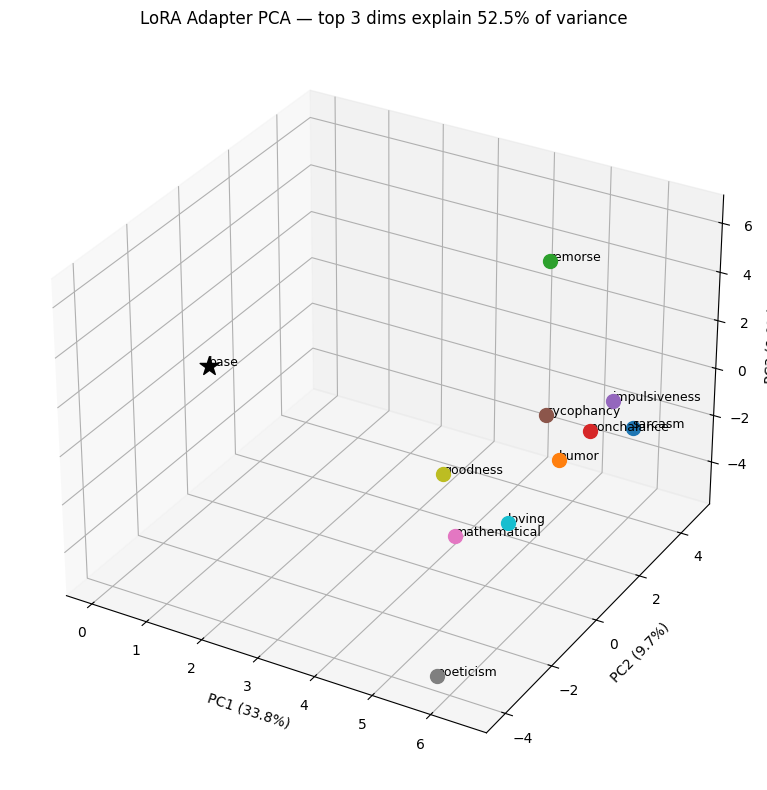

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, persona in enumerate(all_personas):
    x, y, z = coords[i, 0], coords[i, 1], coords[i, 2]
    if persona == "base":
        ax.scatter(x, y, z, s=200, c="black", marker="*")
    else:
        ax.scatter(x, y, z, s=100)
    ax.text(x, y, z, persona, fontsize=9)

ax.set_xlabel(f"PC1 ({explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax.set_zlabel(f"PC3 ({explained[2]:.1%})")
ax.set_title(f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance")
plt.tight_layout()
plt.show()

In [25]:
# Derive cosine similarity matrix from G
norms = torch.sqrt(torch.diag(G))
G_cosine = G / norms.unsqueeze(1) / norms.unsqueeze(0)
G_cosine = torch.nan_to_num(G_cosine, nan=0.0)  # base cosine sim is 0 with everything

# Pretty print
import pandas as pd
df = pd.DataFrame(G_cosine.numpy(), index=all_personas, columns=all_personas)
print(df.round(3))

               base  sarcasm  humor  remorse  nonchalance  impulsiveness  \
base            0.0    0.000  0.000    0.000        0.000          0.000   
sarcasm         0.0    1.000  0.362    0.215        0.295          0.288   
humor           0.0    0.362  1.000    0.236        0.338          0.324   
remorse         0.0    0.215  0.236    1.000        0.223          0.244   
nonchalance     0.0    0.295  0.338    0.223        1.000          0.337   
impulsiveness   0.0    0.288  0.324    0.244        0.337          1.000   
sycophancy      0.0    0.249  0.274    0.278        0.256          0.284   
mathematical    0.0    0.223  0.295    0.212        0.224          0.229   
poeticism       0.0    0.215  0.268    0.179        0.229          0.220   
goodness        0.0    0.201  0.277    0.215        0.222          0.214   
loving          0.0    0.232  0.310    0.247        0.287          0.269   

               sycophancy  mathematical  poeticism  goodness  loving  
base            

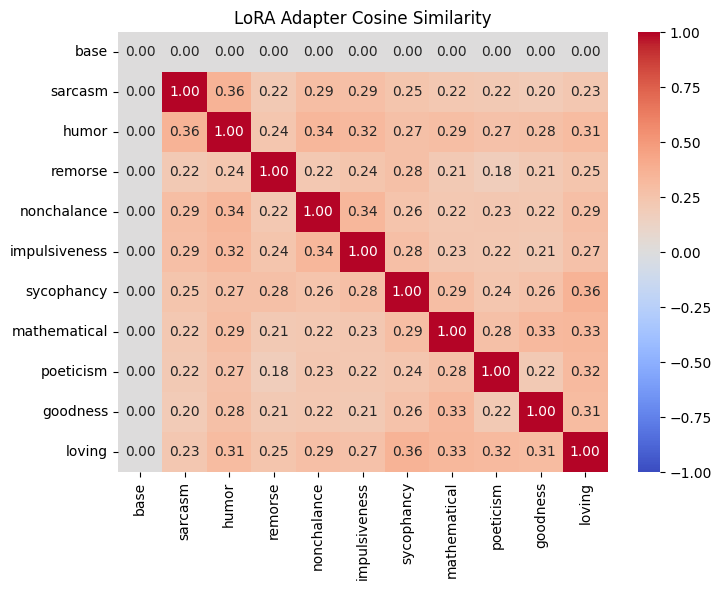

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()